<img src="../../images/arm_logo.png" width=500 alt="ARM Logo"></img>

# Decadal Near-Surface Turbulent Flux Measurements from ARM
---

:::{important} Goal

The goal of this notebook is to showcase decadal analysis using ARM SGP observations
:::

<a href="https://colab.research.google.com/github/ARM-Development/arm-summer-school-2026/blob/main/notebooks/decadal/ecor-ebbr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview

Within this notebook, we will cover the methodology and analysis within @sullivan_over_2025 :
1. History of near 3 decades of ARM's near-surface turbulent flux observations
1. Introduction to the Energy Balance Bowen Ratio (EBBR) and Eddy Covariance (EC) methods
1. Comparison of Sensible and Latent Heat Fluxes from these methods for 2015 to 2023 period at SGP

## Prerequisites
| Concepts | Importance | Notes |
| --- | --- | --- |
| [ACT Basics](../act/ACT-Basics-SGP.ipynb) | Helpful | Basic features |
| [Matplotlib Basics](https://foundations.projectpythia.org/core/matplotlib/) | Helpful | Basic plotting |
| [NumPy Basics](https://foundations.projectpythia.org/core/numpy/) | Helpful | Basic arrays |
| [Xarray Basics](https://foundations.projectpythia.org/core/xarray/) | Helpful | Multi-dimensional arrays |

- **Time to learn**: 15 minutes
---

## History of ARM's Near-Surface Turbulent Flux Observations at SGP

Sensible and latent heat fluxes (*H* and *LE*) are critical to modulating the sources and sinks of the energy and water budgets across the land-atmosphere-biosphere interface. 

In-situ measurements of *H* and *LE* are critical for understanding and predicting processes relevant for heat waves, droughts, argiculture and irrigation scheduling, and are necessary to capture the fine scale scales at which these processes occur. 

The U.S. Department of Energy (DOE) Atmospheric Radiation Measurement (ARM) user facility has measured fluxes primarily using in-situ meteorologically driven energy balance flux gradient method with energy balance Bowen ratio (EBBR) system, the eddy covariance method (EC) with the carbon dioxide flux (CO2FLX), and the eddy correlation (ECOR) flux measurement system. 

ARM began measuring fluxes in 1992 [^imgnote] using the EBBR system at the Southern Great Plains (*SGP*) atmospheric observatory, at ten grassland extended facilities (*EF*) within Oklahoma and Kansas and one *EF* on the northern edge of cropland. THe intention was that these facilities would be representative of a typical global climate model (GCM) grid cell. 

[^imgnote]: Location and Timeline of Flux Measurements at SGP from @sullivan_over_2025
    ```{image} ../../images/figures/sullivan_2025_figure_1.png
    :alt: @sullivan_over_2025 Figure 1
    :width: 4000px
    :align: center
    ```

## The Energy Balence Bowen Ratio (EBBR) Method

The EBBR measures near-surface gradients of temperature and humidty[^ebbr-inst] to approximate the Bowen Ratio:

[^ebbr-inst]: Gradients of temperature and humidity are measured above vegetation height using two sets of aspirated temperature and relative humidity (T /RH; Vaisala HMP45[^vaisala_hmp45]) probes mounted with a vertical separation of 1 m.

[^vaisala_hmp45]: [Vaisala HMP45 Manual](https://www.vaisala.com/sites/default/files/documents/HMP45AD-User-Guide-U274EN.pdf)

```{math}
:label: bowen-ratio
\beta \equiv \frac{H}{LE} \approx \frac{C_p \rho}{\lambda}\frac{\overline{\Delta T}}{\overline{\Delta \rho_v}},
```
where:

- $\beta$ is the Bowen ratio

- $H$ is the sensible heat flux

- $LE$ is the latent heat flux

- $C_p$ is the specific heat of air ($\mathrm{J\ kg^{-1}\ K^{-1}}$)

- $\rho$ is the density of air ($\mathrm{kg\ m^{-3}}$)

- $\lambda$ is the latent heat of vaporization of water (or the latent heat of sublimation for frozen conditions) ($\mathrm{J\ kg^{-1}}$)

- $\overline{\Delta T}$ is the mean temperature difference between the upper and lower sensors ($\mathrm{K}$)

- $\overline{\Delta \rho_v}$ is the mean difference in water vapor density between the upper and lower sensor ($\mathrm{kg\ m^{-3}}$)

EBBR also measures net radiation, soil heat flow, soil temperature, and soil moisture[^ebbr-rad].

[^ebbr-rad]: Net Radation is measured with Radiation and Energy Balance Systems (REBS), Inc, Q*7.1, REBS HFT-3 for soil heat flow, REBS STP-1 for soil temperature, and REBS SMP-2 for soil moisture. 

Combining an equational form of a closed surface energy budget, where the sum of sensible and latent heat fluxes equals the net radiation less energy consumed as the ground heat flux. 

The definition of the Bowen ratio as the ratio of sensible to latent heat flux gives equations for the sensible and latent heat fluxes as:

```{math}
:label: ebbr-energy-balance
R + G = -(H + LE + \text{other components})
```

```{math}
:label: ebbr-h
H = \frac{-(R + G)}{1 + \beta^{-1}}
```

```{math}
:label: ebbr-le
LE = \frac{-(R + G)}{\beta + 1}
```
where
- $R$ is radiation
- $G$ is surface soil heat flux
- $R$, $G$, $H$, and $LE$ are in $\mathrm{W\ m^{-2}}$
- “other components” are assumed to be null

## The Eddy Covariance (EC) Method

The EC method estimates fluxes from the covariance of the vertical wind speed and the quantity of interest:

horizontal wind speed for momentum flux ($\tau$)
```{math}
:label: ec-momentum-flux
\tau = \rho \overline{w' u'}
```
temperature for $H$
```{math}
:label: ec-sensible-heat
H = C_p \rho \overline{w' T'}
```
water vapor concentration for $LE$
```{math}
:label: ec-latent-heat
LE = \lambda \rho \overline{w' X_v'}
```
another scalar (for example, CO$_2$ or CH$_4$ concentration)
```{math}
:label: ec-scalar-flux
F_c = \rho \overline{w' X_c'}
```

where:

- $w'$ is the instantaneous perturbation, used herein as the departure of a given variable from its mean, of the vertical wind speed component ($\mathrm{m\ s^{-1}}$)

- $u'$ is the instantaneous perturbation of the horizontal wind speed component ($\mathrm{m\ s^{-1}}$)

- $T'$ is the instantaneous perturbation of temperature ($\mathrm{K}$)

- $X_v'$ is the instantaneous perturbation of the mixing ratio of water vapor in air ($\mathrm{kg\ kg^{-1}}$)

- $X_c'$ is the instantaneous perturbation of the mixing ratio of scalar $c$ in air ($\mathrm{kg\ kg^{-1}}$)

- the overbar denotes a time-average operator

Accounting for the thermodynamic contribution of temperature fluctuations, $LE$ can be computed as:

```{math}
:label: ec-le-thermo
LE = (1 + \mu \sigma)\left[\overline{w' \rho_v'} + \left(\frac{\rho_v}{T}\right)\overline{w' T'}\right]
```

where:

- $\mu$ is the ratio of molar masses of dry air and water vapor
- $\sigma$ is the ratio of the densities of water vapor and dry air
- and T is the air temperature.

## EBBR and EC Data Ingest

From @sullivan_over_2025, the timelines for the EBBR and EC products:
| Citation | ARM Datastream | Timeline |
| :---:    | :---:          | :---:    |
| @sullivan_sgp_30ecor | ECOR system         | 2015 - 2019 |
| @sullivan_sgp_ecorsf | ECOR with Smartflux | 2019 - 2026 |
| @sullivan_sgp_ebbr   | EBBR                | 2015 - 2023 |

:::{admonition}**If Running these Notebooks on Google CoLab**
You will need to include the Atmospheric data Community Toolkit (ACT) within the python environment.
Uncomment the next line prior to importing the python libraries.

Instructors will provide Google Drive link for staged data. Otherwise, recommended to use ARM's Data Discovery and upload to Colab
:::

In [19]:
# Uncomment if running on CoLab
##!pip install act-atmos>=2.2.23

In [12]:
import glob
import matplotlib.pyplot as plt
from zoneinfo import ZoneInfo

import act

:::{admonition} **Note**
Due to the number of files, data have been staged for use within this notebook.

To run locally, download the data locally via ARM's Data Discovery or ACT Discovery module and change *base_path* directory
:::

In [8]:
# Define the path to the EBBR, ECOR, and EC datasets
base_path = "../data/"
ebbr_files = sorted(glob.glob(base_path + "sgp30ebbrE39.b1/*.nc"))
ecor_files = sorted(glob.glob(base_path + "sgp30ecorE39.b1/*.cdf"))
ecor_sf_files = sorted(glob.glob(base_path + "sgpecorsfE39.b1/*.nc"))

In [9]:
# Read in the EBBR data, keeping only a subset of variables and cleaning up QC flags
ds_ebbr = act.io.read_arm_netcdf(ebbr_files,
                                 keep_variables=["sensible_heat_flux", "latent_heat_flux", "temp_air_top", "wspd_vec_mean", "wdir_vec_mean"],
                                 cleanup_qc=True)

In [10]:
# Read in the ECOR data, keeping only a subset of variables and cleaning up QC flags
ds_ecor = act.io.read_arm_netcdf(ecor_files, 
                                 keep_variables=["h", "lv_e", "wind_dir", "wind_spd", "temp_irga"],
                                 cleanup_qc=True)

In [13]:
# Read in the ECOR-SF data, keeping only a subset of variables and cleaning up QC flags (note variable names are different in this dataset)
ds_ecor_sf = act.io.read_arm_netcdf(ecor_sf_files, 
                                    keep_variables=["sensible_heat_flux", "latent_flux", "wind_direction_from_north", "mean_wind", "air_temperature"],
                                    cleanup_qc=True)

/Users/jrobrien/.vscode-micromamba/envs/arm-summer-school-2026-dev/lib/python3.11/site-packages/act/io/arm.py:157: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ds = xr.open_mfdataset(filenames, **kwargs)
/Users/jrobrien/.vscode-micromamba/envs/arm-summer-school-2026-dev/lib/python3.11/site-packages/act/io/arm.py:157: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set com

## Sensible and Latent Heat Flux Diel Cycles

In [14]:
## --- Clean up the datasets ---
ds_ecor_corr = ds_ecor.where(ds_ecor['h'] > -200).where(ds_ecor['h'] < 2000)
ds_ebbr_corr = ds_ebbr.where(ds_ebbr['sensible_heat_flux'] > -200).where(ds_ebbr['sensible_heat_flux'] < 2000)

In [15]:
# --- Convert to Local time for Diel Cycles ---
# Create Timezone-aware index, converting to local time
chicago_tz = ZoneInfo("America/Chicago")
ecor_sf_index = ds_ecor_sf.indexes["time"].tz_localize("UTC").tz_convert(chicago_tz)
ecor_index = ds_ecor_corr.indexes["time"].tz_localize("UTC").tz_convert(chicago_tz)
ebbr_index = ds_ebbr_corr.indexes["time"].tz_localize("UTC").tz_convert(chicago_tz)

# Assign the new index back to the xarray object
ds_ecor_sf = ds_ecor_sf.assign_coords(time=ecor_sf_index)
ds_ecor_corr = ds_ecor_corr.assign_coords(time=ecor_index)
ds_ebbr_corr = ds_ebbr_corr.assign_coords(time=ebbr_index)

# Now remove the timezone aware information for groupby options
# Will still be in local time!
ds_ecor_sf["time"] = ds_ecor_sf["time"].data.tz_localize(None)
ds_ecor_corr["time"] = ds_ecor_corr["time"].data.tz_localize(None)
ds_ebbr_corr["time"] = ds_ebbr_corr["time"].data.tz_localize(None)

In [16]:
ds_ebbr_corr

<xarray.Dataset> Size: 4MB
Dimensions:             (time: 139116)
Coordinates:
  * time                (time) datetime64[ns] 1MB 2015-12-31T18:00:00 ... 202...
Data variables:
    temp_air_top        (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
    latent_heat_flux    (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
    sensible_heat_flux  (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
    wspd_vec_mean       (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
    wdir_vec_mean       (time) float32 556kB dask.array<chunksize=(48,), meta=np.ndarray>
Attributes: (12/23)
    command_line:                ebbr_ingest -s sgp -f E39
    Conventions:                 ARM-1.0
    process_version:             ingest-ebbr-10.0-0.el6
    dod_version:                 30ebbr-b1-3.0
    input_source:                /data/collection/sgp/sgpebbrE39.00/145160640...
    site_id:                     sgp
    ...                          ...
    AEM_description:             Automatic Exchange Mechanism
    history:                     created by user dsmgr on machine ruby at 201...
    _file_dates:                 ['20160101', '20160102', '20160103', '201601...
    _file_times:                 ['000000', '000000', '000000', '000000', '00...
    _datastream:                 sgp30ebbrE39.b1
    _arm_standards_flag:         1

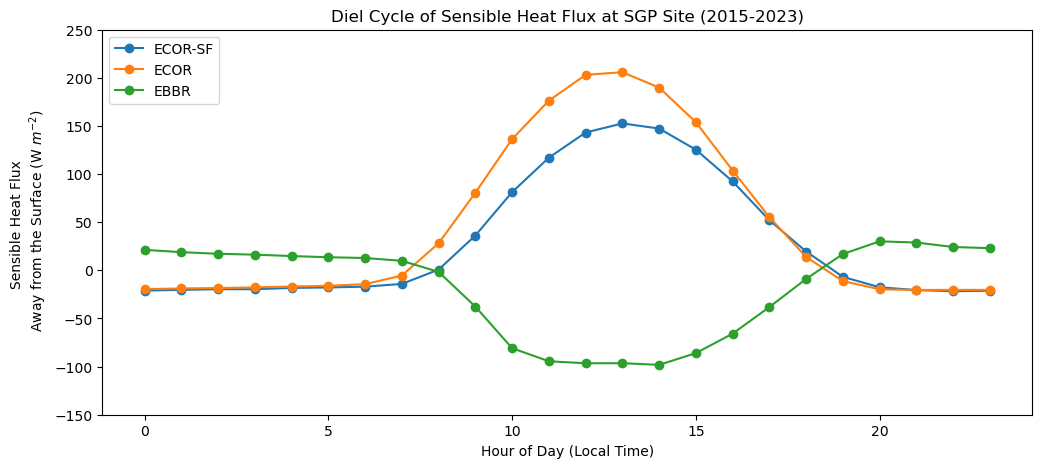

In [18]:
# --- Plot Diel Cycle using xarray grouby function ---
fig, axarr = plt.subplots(1, 1, figsize=(12, 5))

ds_ecor_sf['sensible_heat_flux'].groupby(ds_ecor_sf['time'].dt.hour).mean().plot(marker="o",
                                                                                 ax=axarr,
                                                                                 label="ECOR-SF")
ds_ecor_corr['h'].groupby(ds_ecor_corr['time'].dt.hour).mean().plot(marker="o",
                                                                    ax=axarr,
                                                                    label="ECOR")
ds_ebbr_corr['sensible_heat_flux'].groupby(ds_ebbr_corr['time'].dt.hour).mean().plot(marker="o",
                                                                                         ax=axarr,
                                                                                         label="EBBR")

axarr.set_ylabel(f"Sensible Heat Flux \n Away from the Surface (W $m^{{-2}}$)")
axarr.set_xlabel("Hour of Day (Local Time)")
axarr.set_title("Diel Cycle of Sensible Heat Flux at SGP Site (2015-2023)")
axarr.set_ylim([-150, 250])
axarr.legend(loc="upper left")

## Diel Cycles per Crop Type

From @sullivan_over_2025, at Southern Great Plains Extended Site (E39):
- southerly (100-260&deg;) fetch contains the cropland footprint
- northerly (0-80 and 280-360&deg;) fetch contains the ungrazed grass footprint

In [ ]:
ecor_sf_crop = ds_ecor_sf.where((ds_ecor_sf['wind_direction_from_north'] >= 100) & (ds_ecor_sf['wind_direction_from_north'] <= 260), drop=True)

----